# Deep Learning Technique for Brain Tumor Scans
## Yousuf Ahmed

Tasks:

a) Design a deep learning technique for detecting brain
tumour images from the above given dataset.
b) Validate and evaluate the performance of the model.
c) Write a short report (2000 words max) to describe the
architecture of the model, the training process, main
deep learning challenging problem, your findings and
attempts to cope with the challenging problem and
improve the performance of the AI system.

Criteria:
Keras deep learning package.

In [90]:
!pip list
!pip install tensorflow

Package                           Version
--------------------------------- ------------------
absl-py                           2.1.0
aext-assistant                    4.1.0
aext-assistant-server             4.1.0
aext-core                         4.1.0
aext-core-server                  4.1.0
aext-panels                       4.1.0
aext-panels-server                4.1.0
aext-project-filebrowser-server   4.1.0
aext-share-notebook               4.1.0
aext-share-notebook-server        4.1.0
aext-shared                       4.1.0
aext-toolbox                      4.1.0
aiobotocore                       2.12.3
aiohappyeyeballs                  2.4.0
aiohttp                           3.10.5
aioitertools                      0.7.1
aiosignal                         1.2.0
alabaster                         0.7.16
alembic                           1.13.3
altair                            5.0.1
anaconda-anon-usage               0.4.4
anaconda-catalogs                 0.2.0
anaconda-cli-base    

In [169]:
print(tf.config.list_physical_devices('GPU'))

[]


# Data Pre-Processing and Augmentation
-Makes all Pictures the same size (224 x 224)

-Make all pictures have the same file-name e.g. (N120.jpg or Y120.jpg)

-Make all pictures have the same file type (.jpg)

-Make sure all pictures are of brain scans, filter out incorrect images
(this was a major issue, could use classifier to do this)

-Crop the brain region

Convert to greyscale (Have to convert back to rgb for vgg to work)

In [144]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# ================================
# Step 1: Data Preprocessing
# ================================

dataset_path = "./brain_tumor_dataset"
processed_path = "./processed_dataset"

os.makedirs(f"{processed_path}/yes", exist_ok=True)
os.makedirs(f"{processed_path}/no", exist_ok=True)

def crop_brain_region(image):
    """Crops the brain region from the image using contour detection."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5,5), 0)
    _, thresh = cv2.threshold(blurred, 45, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        return image[y:y+h, x:x+w]
    return image

def augment_image(image, heavier=False):
    """Generates multiple augmentations of the image."""
    augmented_images = []
    
    # Original
    augmented_images.append(image)
    
    # Rotations
    for angle in [cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE]:
        augmented_images.append(cv2.rotate(image, angle))
    
    # Flipping (Not the same as rotations!)
    augmented_images.append(cv2.flip(image, 1))  # Horizontal Flip
    augmented_images.append(cv2.flip(image, 0))  # Vertical Flip
    
    # Brightness Adjustment
    brighter = cv2.convertScaleAbs(image, alpha=1.2, beta=10)
    darker = cv2.convertScaleAbs(image, alpha=0.8, beta=-10)
    augmented_images.append(brighter)
    augmented_images.append(darker)
    
    # If applying heavier augmentation (for 'no' images)
    if heavier:
        # Additional contrast adjustment
        contrast_high = cv2.convertScaleAbs(image, alpha=1.5, beta=15)
        contrast_low = cv2.convertScaleAbs(image, alpha=0.7, beta=-15)
        augmented_images.append(contrast_high)
        augmented_images.append(contrast_low)
        
        # More rotation angles
        for angle in [cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE]:
            augmented_images.append(cv2.rotate(brighter, angle))
            augmented_images.append(cv2.rotate(darker, angle))
    
    return augmented_images

def process_images(input_folder, output_folder, label_prefix, augment=False, heavier_augmentation=False):
    """Processes images: crops, converts to grayscale, resizes, and augments if needed."""
    files = os.listdir(input_folder)
    img_count = 0
    for file in tqdm(files):
        file_path = os.path.join(input_folder, file)
        if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        
        image = cv2.imread(file_path)
        if image is None:
            continue
        
        image = crop_brain_region(image)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)  # Convert grayscale to RGB (3 channels) (for vgg16)
        image = cv2.resize(image, (224, 224))
        
        images_to_save = [image]
        if augment:
            images_to_save.extend(augment_image(image, heavier=heavier_augmentation))
        
        for img in images_to_save:
            new_filename = f"{label_prefix}{img_count}.jpg"
            cv2.imwrite(os.path.join(output_folder, new_filename), img)
            img_count += 1

# Process images (augment both categories, but 'no' gets heavier augmentation)
process_images(f"{dataset_path}/yes", f"{processed_path}/yes", "Y", augment=True, heavier_augmentation=False)
process_images(f"{dataset_path}/no", f"{processed_path}/no", "N", augment=True, heavier_augmentation=True)

100%|██████████| 73/73 [00:00<00:00, 159.72it/s]


# Model Training and Evaluation

Epoch 1/20


C:\Users\yousu\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.5275 - loss: 0.7112 - val_accuracy: 0.6174 - val_loss: 0.6601 - learning_rate: 1.0000e-04
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.6745 - loss: 0.6217 - val_accuracy: 0.6925 - val_loss: 0.5778 - learning_rate: 1.0000e-04
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.7666 - loss: 0.4969 - val_accuracy: 0.7966 - val_loss: 0.4497 - learning_rate: 1.0000e-04
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.8299 - loss: 0.4032 - val_accuracy: 0.8184 - val_loss: 0.4135 - learning_rate: 1.0000e-04
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.8744 - loss: 0.3355 - val_accuracy: 0.8523 - val_loss: 0.3679 - learning_rate: 1.0000e-04
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.8837 - loss: 0.2881 - val_accuracy: 0.7821 - val_loss: 0.4353 - learning_rate: 1.0000e-04
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.88

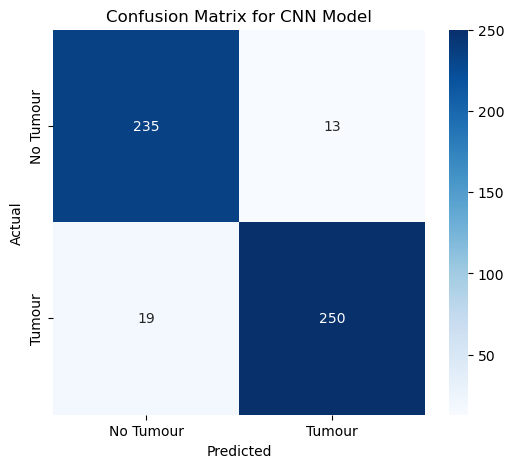

Model saved as brain_tumor_simple_cnn_model.h5


In [167]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Step 2: Load & Prepare Dataset
# ================================

def load_dataset(directory):
    X, y = [], []
    for class_name in ['yes', 'no']:
        class_path = os.path.join(directory, class_name)
        label = 1 if class_name == 'yes' else 0
        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)
            img = cv2.imread(file_path)  # Load in RGB
            img = cv2.resize(img, (224, 224))  # Resize to 224x224
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y)

X, y = load_dataset("./processed_dataset")
X = X.astype('float32') / 255.0  # Normalise pixel values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ================================
# Step 3: Define a Simple CNN Model
# ================================

model = keras.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# ================================
# Step 4: Train the Model
# ================================

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

history = model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=16, callbacks=[early_stopping, reduce_lr])

# ================================
# Step 5: Evaluate the Model
# ================================

y_pred = (model.predict(X_test) > 0.5).astype("int32")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumour', 'Tumour'], yticklabels=['No Tumour', 'Tumour'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for CNN Model')
plt.show()

# ================================
# Step 6: Save the Model
# ================================

model.save("brain_tumor_simple_cnn_model.h5")
print("Model saved as brain_tumor_simple_cnn_model.h5")

# SUMMARY

In [126]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,684,901 (63.65 MB)

 Trainable params: 5,561,633 (21.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,123,268 (42.43 MB)

# PLOTS

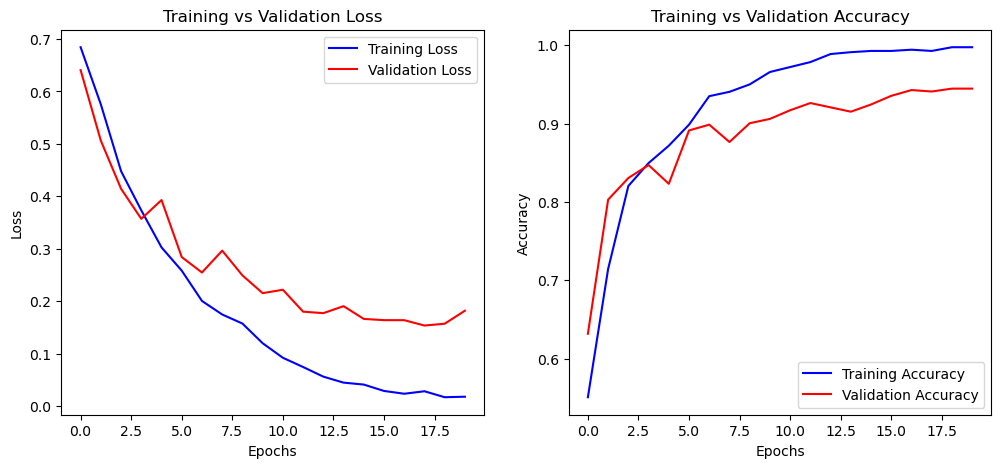

In [128]:
# ================================
# Step 7: Plot Training History
# ================================

def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()

    plt.show()

# Call the function to plot
plot_training_history(history)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


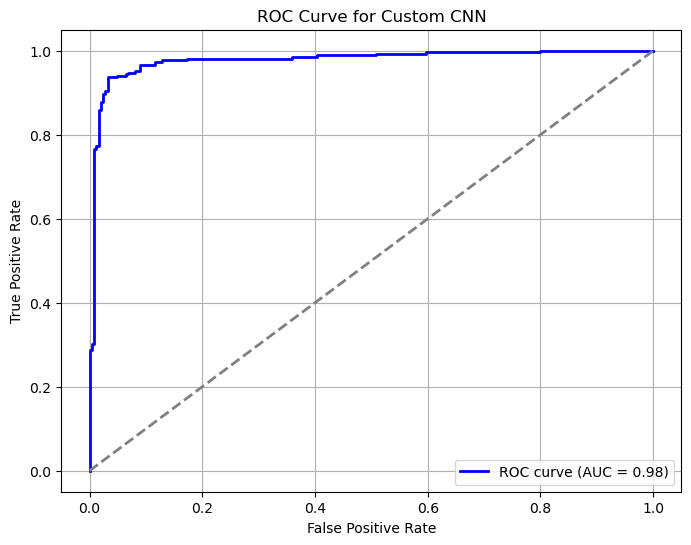

In [153]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(model, X_test, y_test, model_name="Model"):

    # Predict probabilities
    y_prob = model.predict(X_test).ravel()

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=2)  # Diagonal line (random guessing)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {model_name}')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()


plot_roc_curve(model, X_test, y_test, model_name="Custom CNN")

# Testing with extra images

Downloaded a few images into a test folder to check if the model is really working or not.

## Import Model

In [32]:
from tensorflow.keras.models import load_model

model = load_model("brain_tumor_simple_cnn_model.h5")
print("Model loaded successfully!")

Model loaded successfully!


## Process a single image

In [120]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

def process_single_image(image_path, augment=False, heavier_augmentation=False):

    if not isinstance(image_path, str):
        print("Error: Image path must be a string.")
        return None, None

    if not os.path.exists(image_path):
        print(f"Error: File '{image_path}' not found.")
        return None, None
    
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print("Error loading image.")
        return None, None

    # Crop brain region
    image = crop_brain_region(image)
    
    # Convert to grayscale and then back to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    
    # Resize to 224x224
    image = cv2.resize(image, (224, 224))

    images_to_return = [image]

    # Apply augmentations if enabled
    if augment:
        images_to_return.extend(augment_image(image, heavier=heavier_augmentation))

    return images_to_return[0], images_to_return  # Return original processed image + augmented versions

## Show the image is correctly processed

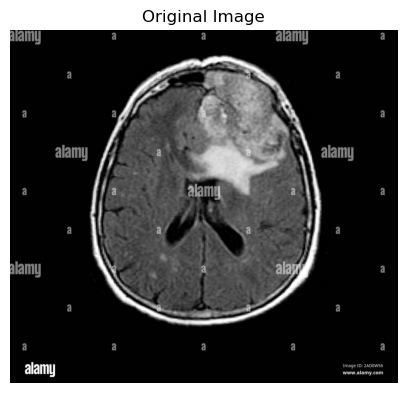

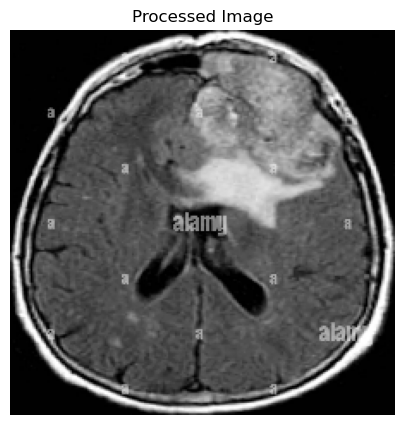

In [124]:
image_path = "test_images/gg.jpg"

# Display the original image
img = cv2.imread(image_path)
plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Original Image")
plt.show()

# Process the image correctly
processed_image, augmented_images = process_single_image(image_path, augment=True, heavier_augmentation=False)

# Display the processed image
if processed_image is not None:
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Processed Image")
    plt.show()

## Check the CNN models accuracy with brain tumor prediction

In [141]:
brain = model.predict(np.expand_dims(resize/255, 0))
brain

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


array([[0.9997582]], dtype=float32)

# Second Model (VGG16) for comparison

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

None
Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 39s 371ms/step - accuracy: 0.6309 - loss: 0.6551 - val_accuracy: 0.8329 - val_loss: 0.4009 - learning_rate: 1.0000e-04
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 38s 367ms/step - accuracy: 0.8592 - loss: 0.3471 - val_accuracy: 0.9298 - val_loss: 0.2438 - learning_rate: 1.0000e-04
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 38s 368ms/step - accuracy: 0.9342 - loss: 0.2092 - val_accuracy: 0.9419 - val_loss: 0.1974 - learning_rate: 1.0000e-04
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 38s 368ms/step - accuracy: 0.9481 - loss: 0.1799 - val_accuracy: 0.9443 - val_loss: 0.1718 - learning_rate: 1.0000e-04
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 38s 369ms/step - accuracy: 0.9765 - loss: 0.1275 - val_accuracy: 0.9492 - val_loss: 0.1484 - learning_rate: 1.0000e-04
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 38s 369ms/step - accuracy: 0.9763 - loss: 0.1065 - val_accuracy: 0.9395 - val_loss: 0.1633 - learning_rate: 1.0000e-04
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3

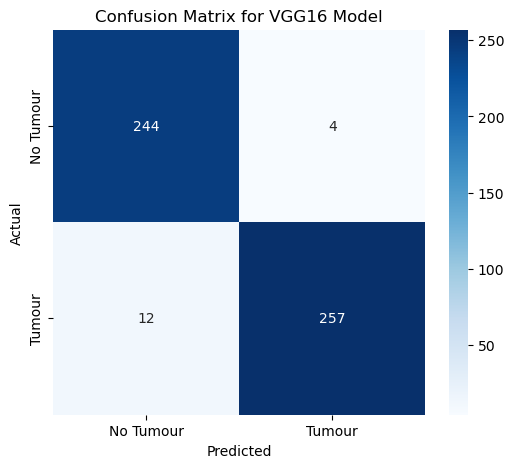

VGG16 Model saved as brain_tumor_vgg16_model.h5


In [149]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Step 1: Load & Prepare Dataset
# ================================

def load_dataset(directory):
    X, y = [], []
    for class_name in ['yes', 'no']:
        class_path = os.path.join(directory, class_name)
        label = 1 if class_name == 'yes' else 0
        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)
            img = cv2.imread(file_path)  # Load in RGB
            img = cv2.resize(img, (224, 224))  # Resize to 224x224
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y)

X, y = load_dataset("./processed_dataset")
X = X.astype('float32') / 255.0  # Normalise pixel values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ================================
# Step 2: Define VGG16 Model
# ================================

# Load pretrained VGG16 model (without top classifier layers)
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze VGG16 layers

# Custom classification head
vgg16_model = keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),  # Prevent overfitting
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile Model
vgg16_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

print(vgg16_model.summary())  # View model architecture

# ================================
# Step 3: Train the VGG16 Model
# ================================

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

history_vgg16 = vgg16_model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=16, callbacks=[early_stopping, reduce_lr])

# ================================
# Step 4: Evaluate VGG16 Model
# ================================

y_pred_vgg16 = (vgg16_model.predict(X_test) > 0.5).astype("int32")
print("\nClassification Report for VGG16 Model:")
print(classification_report(y_test, y_pred_vgg16))

# Confusion Matrix
cm_vgg16 = confusion_matrix(y_test, y_pred_vgg16)
plt.figure(figsize=(6,5))
sns.heatmap(cm_vgg16, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumour', 'Tumour'], yticklabels=['No Tumour', 'Tumour'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for VGG16 Model')
plt.show()

# ================================
# Step 5: Save the VGG16 Model
# ================================

vgg16_model.save("brain_tumor_vgg16_model.h5")
print("VGG16 Model saved as brain_tumor_vgg16_model.h5")

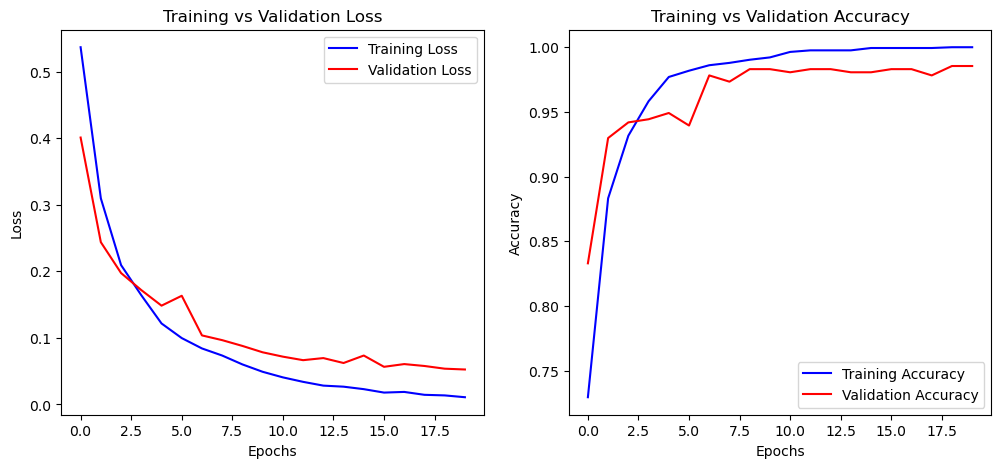

17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 553ms/step


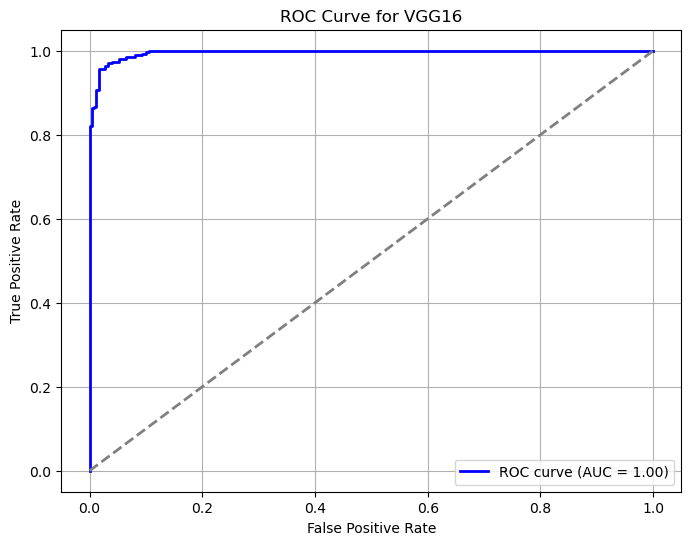

In [157]:
plot_training_history(history_vgg16)
plot_roc_curve(vgg16_model, X_test, y_test, model_name="VGG16")

## Check VGG16 accuracy

In [159]:
brain = vgg16_model.predict(np.expand_dims(resize/255, 0))
brain

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


array([[0.98092645]], dtype=float32)